In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from matplotlib_venn import venn2, venn3, venn3_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

# Load in processed anndata

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
adata.uns['phase_colors'] = ['#ad3803', '#56b567', 'gold']
sc.logging.print_memory_usage()
adata

Memory usage: current 2.38 GB, difference +2.38 GB
CPU times: user 510 ms, sys: 2.17 s, total: 2.68 s
Wall time: 5.47 s


/home/jrcwycy/miniconda3/envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variance

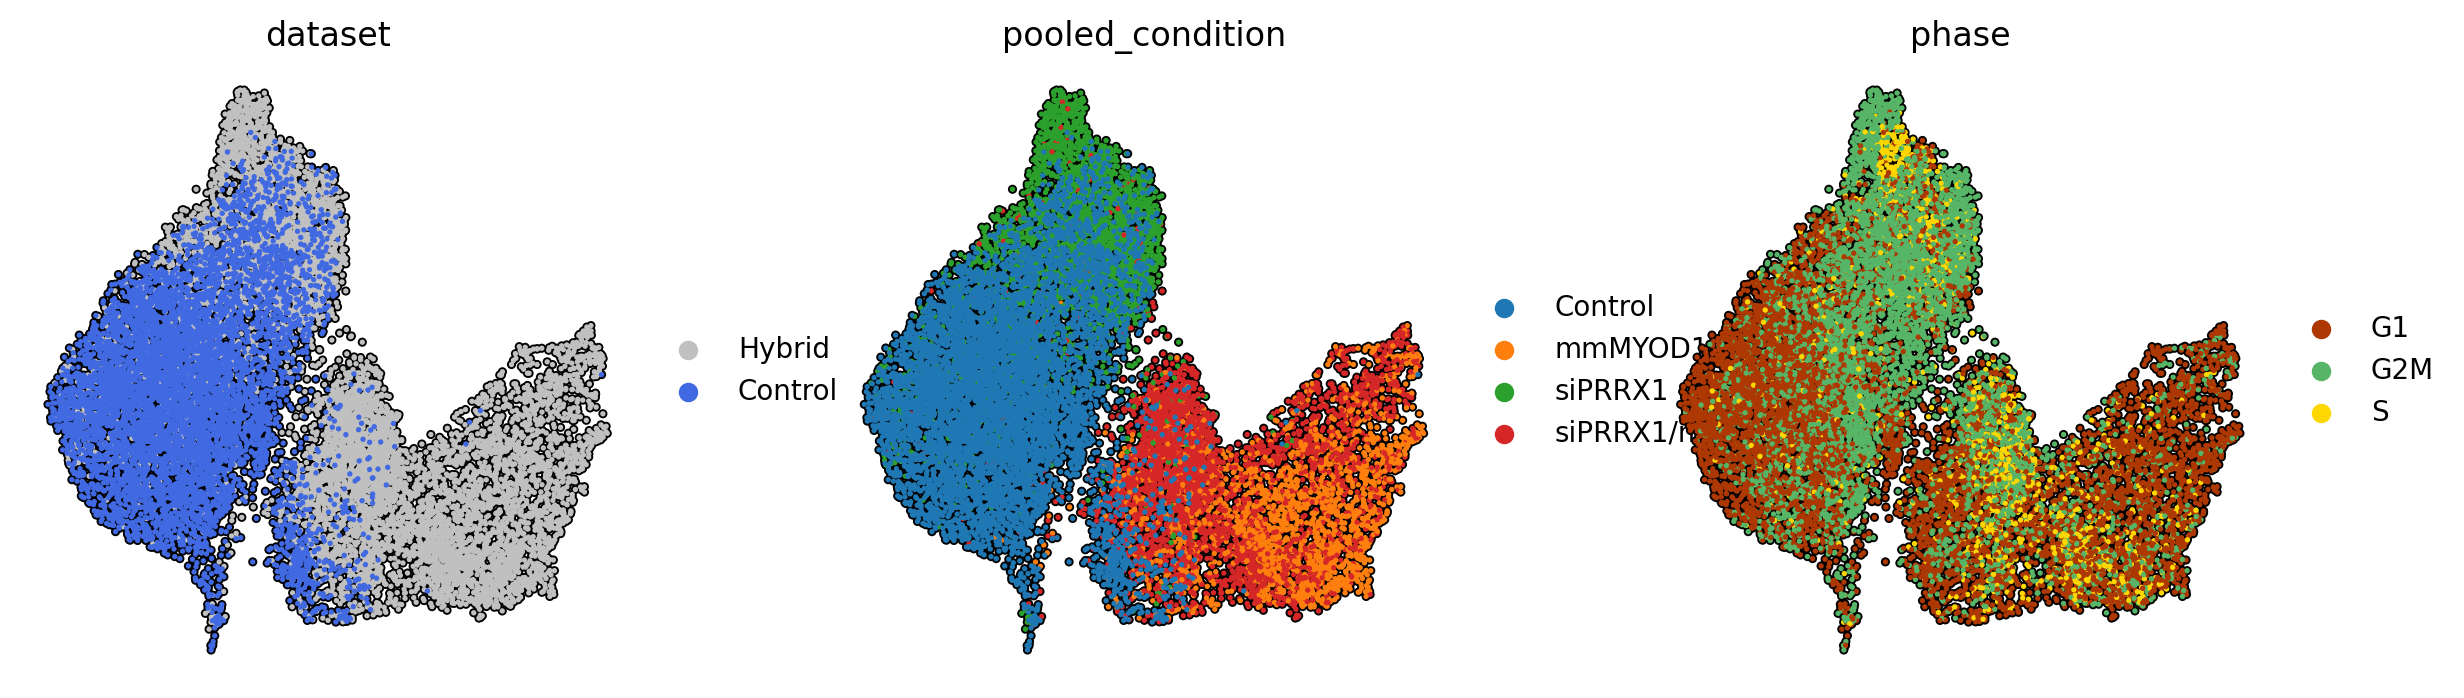

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'phase'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Load in gene sets

In [4]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [17]:
[col for col in geneset.columns if 'g1/s' in col.lower()]

['G1/S Transition of Mitotic Cell Cycle (GO:0000082)',
 'Cell Cycle G1/S Phase Transition (GO:0044843)',
 'Mitotic G1/S Transition Checkpoint Signaling (GO:0044819)',
 'Negative Regulation of G1/S Transition of Mitotic Cell Cycle (GO:2000134)',
 'Negative Regulation of Cell Cycle G1/S Phase Transition (GO:1902807)',
 'Positive Regulation of G1/S Transition of Mitotic Cell Cycle (GO:1900087)',
 'Positive Regulation of Cell Cycle G1/S Phase Transition (GO:1902808)',
 'Regulation of G1/S Transition of Mitotic Cell Cycle (GO:2000045)',
 'Regulation of Cell Cycle G1/S Phase Transition (GO:1902806)']

In [5]:
cc_cols_to_keep = [
    # G1/S transition
    'G1/S Transition of Mitotic Cell Cycle (GO:0000082)',
    # 'Cell Cycle G1/S Phase Transition (GO:0044843)',
    # 'Regulation of Cell Cycle G1/S Phase Transition (GO:1902806)',
    'Regulation of G1/S Transition of Mitotic Cell Cycle (GO:2000045)',

    # G2/M transition
    'G2/M Transition of Mitotic Cell Cycle (GO:0000086)',
    # 'Cell Cycle G2/M Phase Transition (GO:0044839)',
    # 'Regulation of Cell Cycle G2/M Phase Transition (GO:1902749)',
    'Regulation of G2/M Transition of Mitotic Cell Cycle (GO:0010389)',

    # Checkpoints
    'Mitotic G1/S Transition Checkpoint Signaling (GO:0044819)',
    'Mitotic G2/M Transition Checkpoint (GO:0044818)',
    # 'Regulation of G0 to G1 Transition (GO:0070316)',
]

geneset_filt = geneset[cc_cols_to_keep]
print(geneset_filt.shape)
geneset_filt.head()

geneset_filt = geneset_filt.melt(value_name='gene_name', var_name='GO_term')
geneset_filt = geneset_filt.dropna(subset=['gene_name'])

geneset_filt["transition"] = geneset_filt["GO_term"].apply(
    lambda x: "G1S_transition" if "G1/S" in x else 
              ("G2M_transition" if "G2/M" in x else None)
)

cell_cycle_df = (
    geneset_filt
    .assign(value=True)
    .pivot_table(index="gene_name", columns="transition", values="value", aggfunc='any', fill_value=False).astype(bool)
)

cell_cycle_df = cell_cycle_df.reset_index()
cell_cycle_df.columns.name = None
print(cell_cycle_df.shape)
cell_cycle_df.head()

(2250, 6)
(270, 3)


,gene_name,G1S_transition,G2M_transition
0,ACTL6B,True,False
1,ACVR1,True,False
2,ADAM17,True,False
3,ADAMTS1,True,False
4,AIF1,True,False


## Cell cycle

In [6]:
# GO cell cycle genes from Cooper
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
print(cdf.shape)
cdf.head()

# Merge into 1 GO df
merge_cdf = cell_cycle_df.merge(cdf, how='outer', on='gene_name')
print(merge_cdf.shape)
merge_cdf.head()


# Add regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
regev_genes = [x.strip() for x in open(fpath)]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]


def add_missing_genes(df, gene_dict, gene_col='gene_name'):
    result = df.copy()
    for target_col, gene_list in gene_dict.items():
        for gene in gene_list:
            if gene in set(result[gene_col]):
                # Update existing row(s) → force target_col to True
                result.loc[result[gene_col] == gene, target_col] = True
            else:
                # Create a new row with all False except target_col
                new_row = {col: False for col in result.columns if col != gene_col}
                new_row[target_col] = True
                new_row[gene_col] = gene
                result = pd.concat([result, pd.DataFrame([new_row])], ignore_index=True)

    return result


cdf_final = add_missing_genes(
    merge_cdf,
    {'S Phase': s_genes, 'G2 Phase': g2m_genes},
)

print(cdf_final.shape)
cdf_final.head()

(142, 7)
(325, 9)
(409, 9)


,gene_name,G1S_transition,G2M_transition,G1 Phase,G1/S Transition Checkpoint Signaling,G2 Phase,G2/M Transition Checkpoint Signaling,M Phase,S Phase
0,ABCB1,NaN,NaN,False,False,False,True,False,False
1,ACTL6B,True,False,NaN,NaN,NaN,NaN,NaN,NaN
2,ACVR1,True,False,NaN,NaN,NaN,NaN,NaN,NaN
3,ACVR1B,NaN,NaN,False,True,False,False,False,False
4,ADAM17,True,False,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# extract list of all cell cycle genes
cc_genes = cdf_final['gene_name'].unique()
cc_genes = [g for g in cc_genes if g in adata.var_names]
print(f"N cell cycle genes: {len(cc_genes)}")


# get just G1/S genes
G1S_genes = []

for phase in ['G1 Phase', 'G1S_transition', 'S Phase']:
    genes_in_col = cdf_final.loc[cdf_final[phase].astype(bool), 'gene_name'].tolist()
    G1S_genes.extend(genes_in_col)

G1S_genes = list(set(G1S_genes)) # keep only unique genes
G1S_genes = [g for g in G1S_genes if g in adata.var_names]
print(f"N G1/S phase genes: {len(G1S_genes)}")
    
# get just G2/M genes
G2M_genes = []

for phase in ['G2 Phase', 'G2M_transition', 'M Phase']:
    genes_in_col = cdf_final.loc[cdf_final[phase].astype(bool), 'gene_name'].tolist()
    G2M_genes.extend(genes_in_col)

G2M_genes = list(set(G2M_genes)) # keep only unique genes
G2M_genes = [g for g in G2M_genes if g in adata.var_names]
print(f"N G2/M phase genes: {len(G2M_genes)}")

N cell cycle genes: 374
N G1/S phase genes: 299
N G2/M phase genes: 300


In [5]:
# # GO cell cycle genes
# fpath = "../../resources/human_cell_cycle_genes.csv"
# cdf = pd.read_csv(fpath)
# go_cc_genes = cdf['gene_name'].unique()
# # print(f"N unique GO cell cycle genes: {cdf['gene_name'].nunique()}")

# # Regev cell cycle genes
# fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
# regev_genes = [x.strip() for x in open(fpath)]
# s_genes = regev_genes[:43]
# g2m_genes = regev_genes[43:]


# cc_genes = list(set(go_cc_genes) | set(regev_genes))
# print(f"N unique CC genes: {len(cc_genes)}")


# phase_map = {
#     'G1': 'G1 Phase',
#     'G1/S_transition': 'G1/S Transition Checkpoint Signaling',
#     'S': 'S Phase',
#     'G2': 'G2 Phase',
#     'G2/M_transition': 'G2/M Transition Checkpoint Signaling',
#     'M': 'M Phase',
# }

# cc_dict = {
#     short_name: cdf.loc[cdf[col_name] == True, 'gene_name'].tolist()
#     for short_name, col_name in phase_map.items()
# }

# for gene in s_genes:
#     if gene not in cc_dict["S"]:
#         cc_dict["S"].append(gene)

# cc_dict["G2M"] = list(g2m_genes)

# # Remove unique G2 and M keys, add to G2M key
# for gene in cc_dict.get("G2", []) + cc_dict.get("M", []):
#     if gene not in cc_dict["G2M"]:
#         cc_dict["G2M"].append(gene)
        
        
# cc_dict.pop("G2", None)
# cc_dict.pop("M", None)

# print(cc_dict.keys())


# # Make list of G1/S genes from cc_dict
# G1S_genes = []
# for phase in ["G1", "G1/S_transition", "S"]:
#     G1S_genes.extend(cc_dict[phase])
# G1S_genes = [str(g) for g in G1S_genes]
# G1S_genes_unique = list(dict.fromkeys(G1S_genes))
# G1S_genes_filtered = [g for g in G1S_genes_unique if g in adata.var_names]
# print(f"N G1/S genes: {len(G1S_genes_filtered)}")
    
    
# # Make list of G2/M genes from cc_dict 
# G2M_genes = []
# for phase in ["G2/M_transition", "G2M"]:
#     G2M_genes.extend(cc_dict[phase])
# G2M_genes = [str(g) for g in G2M_genes]
# G2M_genes_unique = list(dict.fromkeys(G2M_genes))
# G2M_genes_filtered = [g for g in G2M_genes_unique if g in adata.var_names]
# print(f"N G2M genes: {len(G2M_genes_filtered)}")

N unique CC genes: 235
dict_keys(['G1', 'G1/S_transition', 'S', 'G2/M_transition', 'G2M'])
N G1/S genes: 119
N G2M genes: 104


## Quiescence genes

In [8]:
fpath = "../../resources/genes_for_scoring.csv"

df = pd.read_csv(fpath)
print(df.shape)
print(df.columns.tolist())

qui_genes = [gene for gene in df['quiescence'].unique() if gene in adata.var_names]
print(len(qui_genes))

df.head()

(512, 18)
['G1/S_transition', 'G2/M_transition', 'CC_checkpoints', 'Cell_cycle_reg', 'Pos_proliferation', 'Neg_proliferation', 'quiescence', 'AS', 'Chromatin', 'Circadian', 'Core_repro', 'NOTCH_signaling', 'Asymm_PCP', 'FOXO', 'p53_acyivity', 'DREAM/negE2F', 'senes_stress', 'sasp']
59


,G1/S_transition,G2/M_transition,CC_checkpoints,Cell_cycle_reg,Pos_proliferation,Neg_proliferation,quiescence,AS,Chromatin,Circadian,Core_repro,NOTCH_signaling,Asymm_PCP,FOXO,p53_acyivity,DREAM/negE2F,senes_stress,sasp
0,FBXW7,CDC25A,CHFR,YTHDF2,EMP2,IGFBP5,ATF3,CWC27,H2AJ,TEF,HDAC9,FBXW7,SMURF2,TXN,MAPK11,CDC25A,H2AZ2,H2AZ2
1,CCNP,CDK6,CDK1,PRKCA,TNXB,ZBTB7C,ATF4,DDX20,HCFC1,SFPQ,POLR2C,ST3GAL4,SMURF1,PLXNA4,TPX2,CDK1,ACD,H2BC9
2,EZH2,NES,MRNIP,OBSL1,CX3CL1,NTRK1,CTNNB1,RBM3,INO80E,THRAP3,PTN,FCER2,WNT5A,SOD2,TAF9B,E2F1,H2BC9,JUN
3,APBB1,CDK1,DGKZ,LOC102724428,CCND2,KDF1,BACH2,RBM5,HDAC8,NKX2-1,JUN,PSMA7,SCRIB,KAT2B,DYRK2,LIN52,H2BC4,UBE2C
4,DDX3X,FBXL15,BARD1,MAGEA4,LIG4,BTG3,JUN,RBM23,BAZ2A,LOC102724428,MED31,TBL1X,PSMC6,IGFBP1,MDM4,RBL1,H2BC5,H2BC4


# DGE

In [9]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    
    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
        else:
            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

## By condition

mmMYOD1, siPRRX1, siPRRX1/mmMYOD1, Controls

In [10]:
# # all groups vs each other
# sc.tl.rank_genes_groups(
#     adata, 
#     groupby="pooled_condition",
#     method='wilcoxon',
#     corr_method='benjamini-hochberg',
#     use_raw=False,
#     layer='log_norm',
#     pts=True,
#     key_added='each_vs_rest',
# )

# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_control',
)

ranking genes
    finished (0:01:20)


In [11]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_vs_control',
)

sig = get_significant_DEGs(deg)
sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 9882



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513
1,mmMYOD1,MT-ND4,69.559166,2.778089,0.0,0.0,0.999526,2.778089
2,mmMYOD1,LINC-PINT,59.171329,2.708041,0.0,0.0,0.970128,2.708041
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306


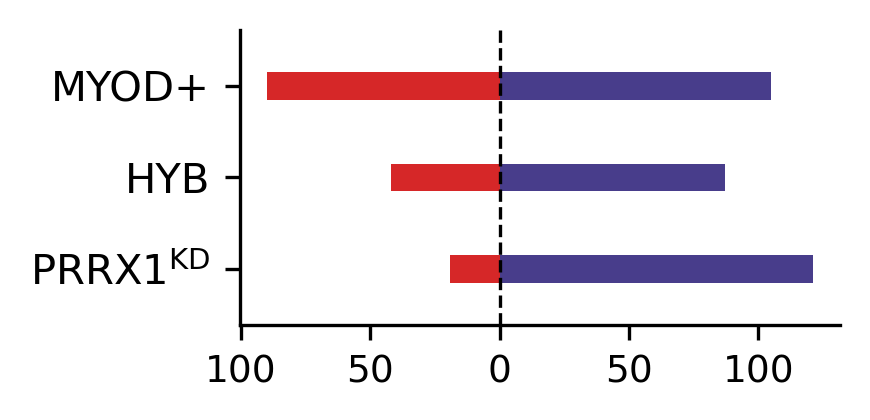

In [96]:
# Get DE cell cycle genes
tmp = sig.copy()
tmp = tmp[tmp['names'].isin(cc_genes)]

tmp['direction'] = tmp['logfoldchanges'].apply(lambda x: 'up' if x > 0 else 'down')
counts = tmp.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)

plot_order = ['siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
plot_df = plot_df.reindex(plot_order)

group_labels = [r'PRRX1$^{\mathrm{KD}}$', 'HYB', 'MYOD+']


plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3, 1.5
fig, ax = plt.subplots()

bar_width = 0.3

ax.barh(plot_df.index, plot_df['up'], color='darkslateblue', label='Up', height=bar_width)
ax.barh(plot_df.index, plot_df['down'], color='tab:red', label='Down', height=bar_width)

ax.axvline(0, color='k', linewidth=0.8, ls='--')

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(group_labels)
ax.margins(y=0.2)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: int(abs(x))))
ax.tick_params(axis='x', labelsize=9)

sns.despine()
plt.tight_layout()
plt.show()

## By condition and phase

In [12]:
phase_group_map = {
    "G1": "G1/S",
    "S": "G1/S",
    "G2M": "G2/M"
}

adata.obs["condition_by_phase_group"] = (
    adata.obs["pooled_condition"].astype(str) + "_" +
    adata.obs["phase"].map(phase_group_map)
)

# Make categorical and optionally order
conditions = ["Control", "mmMYOD1", "siPRRX1", "siPRRX1/mmMYOD1"]
phase_groups = ["G1/S", "G2/M"]
ordered_categories = [f"{cond}_{ph}" for ph in phase_groups for cond in conditions]

adata.obs["condition_by_phase_group"] = pd.Categorical(
    adata.obs["condition_by_phase_group"],
    categories=ordered_categories,
    ordered=True
)

adata.obs["condition_by_phase_group"].value_counts(sort=False)

condition_by_phase_group
Control_G1/S            3770
mmMYOD1_G1/S            1733
siPRRX1_G1/S            1936
siPRRX1/mmMYOD1_G1/S    2415
Control_G2/M            3190
mmMYOD1_G2/M             376
siPRRX1_G2/M            1494
siPRRX1/mmMYOD1_G2/M    1036
Name: count, dtype: int64

In [14]:
# hyb G1S vs control G1S
sc.tl.rank_genes_groups(
    adata, 
    groupby='condition_by_phase_group',
    groups=['mmMYOD1_G1/S', 'siPRRX1_G1/S', 'siPRRX1/mmMYOD1_G1/S'], 
    reference='Control_G1/S',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_G1S',
)

# hyb G2M vs control G2M
sc.tl.rank_genes_groups(
    adata, 
    groupby='condition_by_phase_group',
    groups=['mmMYOD1_G2/M', 'siPRRX1_G2/M', 'siPRRX1/mmMYOD1_G2/M'], 
    reference='Control_G2/M',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_G2M',
)

ranking genes
    finished (0:00:38)
ranking genes
    finished (0:00:27)


In [15]:
deg1 = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='deg_G1S',
)

deg2 = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='deg_G2M',
)

sig_g1s = get_significant_DEGs(deg1)
sig_g2m = get_significant_DEGs(deg2)

print(sig_g1s.shape)
print(sig_g2m.shape)

sig_g1s.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 9704

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 7052

(20553, 8)
(13705, 8)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1_G1/S,MYOD1,59.674854,32.257271,0.0,0.0,1.000000,32.257271
1,mmMYOD1_G1/S,MT-ND4,59.555641,2.864464,0.0,0.0,0.999423,2.864464
2,mmMYOD1_G1/S,LINC-PINT,51.100346,2.808635,0.0,0.0,0.970571,2.808635
3,mmMYOD1_G1/S,NAV3,50.168304,3.564665,0.0,0.0,0.921523,3.564665
4,mmMYOD1_G1/S,KCNQ5,50.139122,3.633818,0.0,0.0,0.950375,3.633818


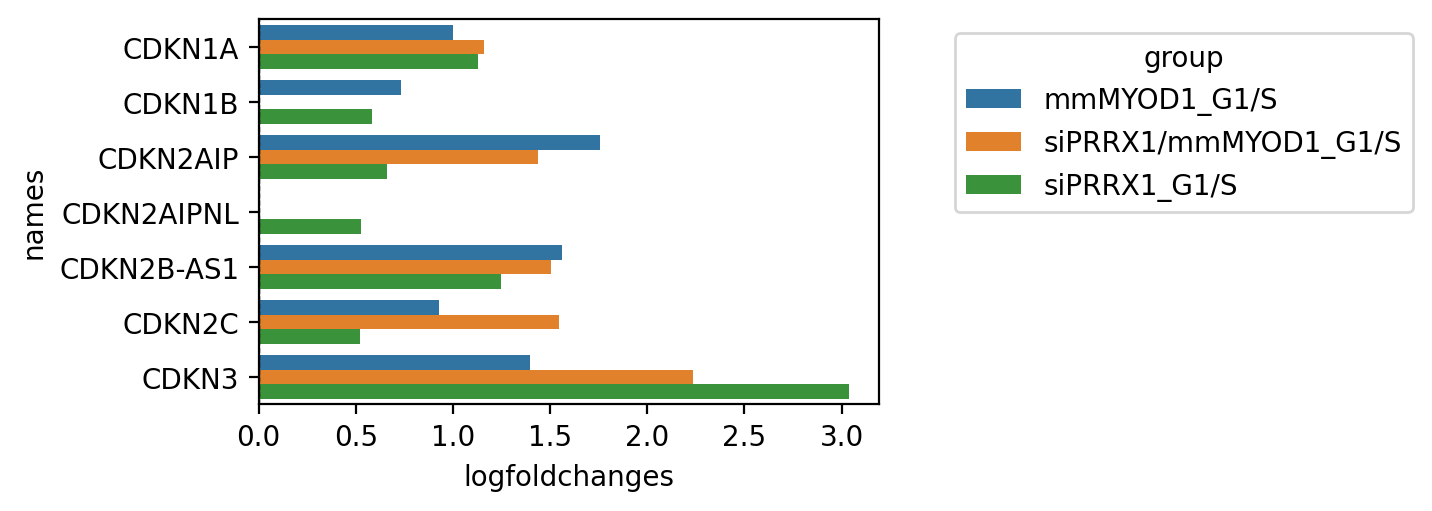

In [30]:
query = 'CDKN'

tmp = sig_g1s.copy()

tmp = tmp[tmp['names'].str.startswith(query)]

tmp = tmp.sort_values(by='names')


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 2.5

sns.barplot(
    data=tmp,
    x='logfoldchanges',
    y='names',
    hue='group',
)

plt.axvline(x=0, ls='--', color='k', lw=0.5)

sns.move_legend(plt.gca(), loc='upper left', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()

# Cell cycle DEGs

In [16]:
print(len(cc_genes))
print(len(G1S_genes))
print(len(G2M_genes))

g1s_unique = list(set(G1S_genes) - set(G2M_genes))
g2m_unique = list(set(G2M_genes) - set(G1S_genes))

print(f"Unique to G1/S: {len(g1s_unique)}")
print(f"Unique to G2/M: {len(g2m_unique)}")

# intersection check
print(f"\nShared genes: {len(set(G1S_genes) & set(G2M_genes))}")

374
299
300
Unique to G1/S: 74
Unique to G2/M: 75

Shared genes: 225


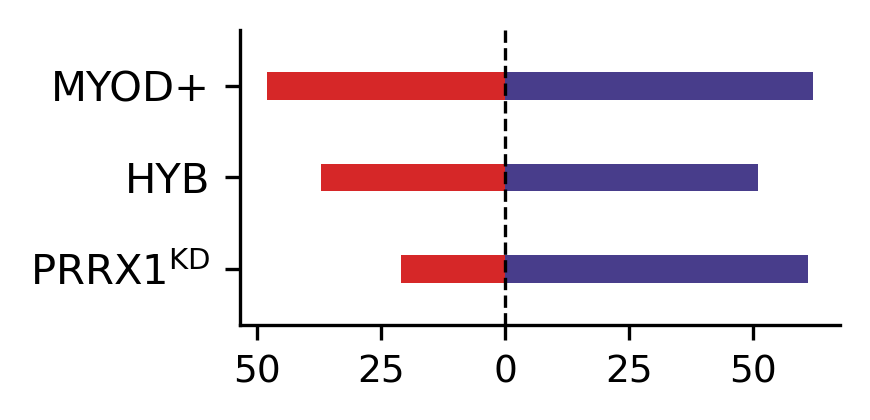

In [100]:
phase = 'G2/M'

if phase == 'G1/S':
    tmp = sig_g1s.copy()
    tmp = tmp[tmp['names'].isin(G1S_genes)]
elif phase == 'G2/M':
    tmp = sig_g2m.copy()
    tmp = tmp[tmp['names'].isin(G2M_genes)]
    
    
tmp['direction'] = tmp['logfoldchanges'].apply(lambda x: 'up' if x > 0 else 'down')
counts = tmp.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)

plot_order = [f'siPRRX1_{phase}', f'siPRRX1/mmMYOD1_{phase}', f'mmMYOD1_{phase}']
plot_df = plot_df.reindex(plot_order)

# group_labels = [rf'PRRX1$^{{\mathrm{{KD}}}}$ ({phase})', f'HYB ({phase})', f'MYOD+ ({phase})']
group_labels = [r'PRRX1$^{\mathrm{KD}}$', 'HYB', 'MYOD+']

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3, 1.5
fig, ax = plt.subplots()

bar_width = 0.3

ax.barh(plot_df.index, plot_df['up'], color='darkslateblue', label='Up', height=bar_width)
ax.barh(plot_df.index, plot_df['down'], color='tab:red', label='Down', height=bar_width)

ax.axvline(0, color='k', linewidth=0.8, ls='--')

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(group_labels)
ax.margins(y=0.2)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: int(abs(x))))
ax.tick_params(axis='x', labelsize=9)

sns.despine()
plt.tight_layout()
plt.show()

In [21]:
sig = sig_g1s.copy()

# sig = sig[sig['names'].isin(g1s_unique)]
sig = sig[sig['names'].isin(G1S_genes)]
print(f"Total genes: {sig['names'].nunique()}\n")
print(f"{sig.groupby('group')['names'].nunique()}\n")


sig.head()

Total genes: 212

group
mmMYOD1_G1/S            162
siPRRX1/mmMYOD1_G1/S    152
siPRRX1_G1/S            158
Name: names, dtype: int64



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
9,mmMYOD1_G1/S,GMNN,42.279690,2.874611,0.000000e+00,0.000000e+00,0.863243,2.874611
66,mmMYOD1_G1/S,DPF3,31.182261,4.584214,1.853860e-213,1.732252e-211,0.564339,4.584214
80,mmMYOD1_G1/S,UBE2E2,29.863449,2.053181,5.872744e-196,4.985263e-194,0.717830,2.053181
147,mmMYOD1_G1/S,PSME2,26.678431,0.794715,8.377099e-157,5.154283e-155,0.915176,0.794715
165,mmMYOD1_G1/S,KMT2E,26.172537,1.607726,5.460650e-151,3.129190e-149,0.727640,1.607726


In [22]:
direction = 'Upregulated'

if direction == 'Upregulated':
    tmp = sig[sig['logfoldchanges'] > 0]
else:
    tmp = sig[sig['logfoldchanges'] < 0]

tmp = tmp.sort_values(by=['group', 'names'])

print(f"{direction} cell cycle genes\n")

myod_genes = set(tmp[tmp['group'] == 'mmMYOD1_G1/S']['names'].unique())
prrx_genes = set(tmp[tmp['group'] == 'siPRRX1_G1/S']['names'].unique())
hyb_genes = set(tmp[tmp['group'] == 'siPRRX1/mmMYOD1_G1/S']['names'].unique())

print(f"Unique to mmMYOD1: {sorted(myod_genes - prrx_genes - hyb_genes)}\n")
print(f"Unique to siPRRX1: {sorted(prrx_genes - myod_genes - hyb_genes)}\n")
print(f"Unique to siPRRX1/mmMYOD1: {sorted(hyb_genes - myod_genes - prrx_genes)}\n")

print(f"Shared between mmMYOD1 + siPRRX1: {sorted((prrx_genes.intersection(myod_genes)) - hyb_genes)}\n")
print(f"Shared between mmMYOD1 + siPRRX1/mmMYOD1: {sorted((hyb_genes.intersection(myod_genes)) - prrx_genes)}\n")
print(f"Shared between siPRRX1 + siPRRX1/mmMYOD1: {sorted((hyb_genes.intersection(prrx_genes)) - myod_genes)}\n")
print(f"Shared by all: {sorted(hyb_genes.intersection(prrx_genes).intersection(myod_genes))}\n")

Upregulated cell cycle genes

Unique to mmMYOD1: ['ACVR1B', 'BCL7B', 'CACUL1', 'CCL2', 'CCNH', 'CDK6', 'E2F3', 'EGFR', 'HINFP', 'INHBA', 'LATS2', 'LSM10', 'MNAT1', 'MRNIP', 'SDE2', 'TERF2IP', 'TP53', 'WAC', 'ZNF830']

Unique to siPRRX1: ['APPL2', 'AVEN', 'BABAM1', 'BRCC3', 'CCNG1', 'CPSF3', 'E2F8', 'HBS1L', 'HSPA8', 'MCM6', 'MRE11', 'NABP2', 'NAE1', 'PBRM1', 'POLA1', 'RBL2', 'RRM1', 'SMARCB1', 'SMARCC2', 'TAOK2', 'TMEM14B', 'UNG', 'ZNF367']

Unique to siPRRX1/mmMYOD1: ['CDC25A', 'DPF1', 'KIF14', 'POLD3', 'USP1']

Shared between mmMYOD1 + siPRRX1: ['ATM', 'BCL7A', 'CDKN1B', 'CUL1', 'GSPT1', 'INIP', 'PSME3', 'SLBP', 'SMARCD3', 'TAOK3']

Shared between mmMYOD1 + siPRRX1/mmMYOD1: ['ACVR1', 'BRD4', 'CCND3', 'CDC73', 'CDK7', 'DCUN1D3', 'HUS1', 'KLF4', 'MYC', 'NABP1', 'PLK3', 'PPP2CA', 'PRKD2', 'RPA2', 'ZNF655']

Shared between siPRRX1 + siPRRX1/mmMYOD1: ['CCNB2', 'CDCA7', 'CDK2', 'CHAF1B', 'GINS2', 'IQGAP3', 'MCM2', 'MCM5', 'MSH2', 'PCNA', 'PRIM1', 'RAD51', 'SMARCA2', 'TYMS', 'UBR7', 'WDR76'

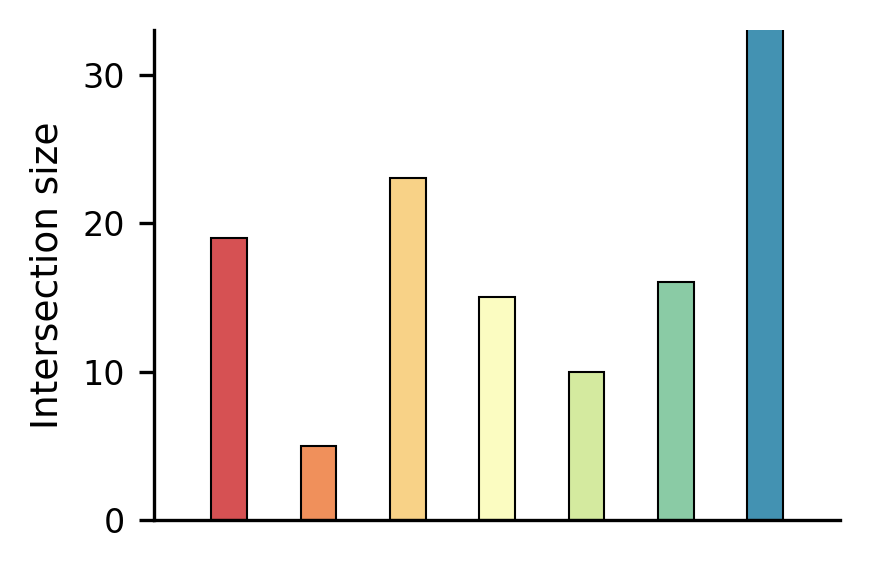

In [23]:
ordered_conditions = [
    'unique_myod',
    'unique_hyb',
    'unique_prrx',
    'shared_myod_hyb',
    'shared_myod_prrx',
    'shared_prrx_hyb',
    'shared_all',
]

data = {
    'condition': ordered_conditions,
    'gene_count': [
        len(myod_genes - prrx_genes - hyb_genes),
        len(hyb_genes - myod_genes - prrx_genes),
        len(prrx_genes - myod_genes - hyb_genes),
        len((myod_genes.intersection(hyb_genes)) - prrx_genes),
        len((myod_genes.intersection(prrx_genes)) - hyb_genes),
        len((hyb_genes.intersection(prrx_genes)) - myod_genes),
        len(hyb_genes.intersection(prrx_genes).intersection(myod_genes)),
    ]
}

plot_df = pd.DataFrame(data)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3, 2

sns.barplot(
    x='condition',
    y='gene_count',
    data=plot_df,
    hue='condition',
    palette='Spectral',
    width=0.4,
    ec='k',
    linewidth=0.5,
    saturation=0.9,
)

ax = plt.gca()
ax.tick_params(axis='x', bottom=False)
ax.set_xticklabels([])

ax.margins(x=0.1)

plt.ylim([0, 33])

plt.xlabel('')
plt.ylabel('Intersection size', fontsize=9)
# plt.xticks(rotation=90)#, ha='right')
plt.yticks(fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

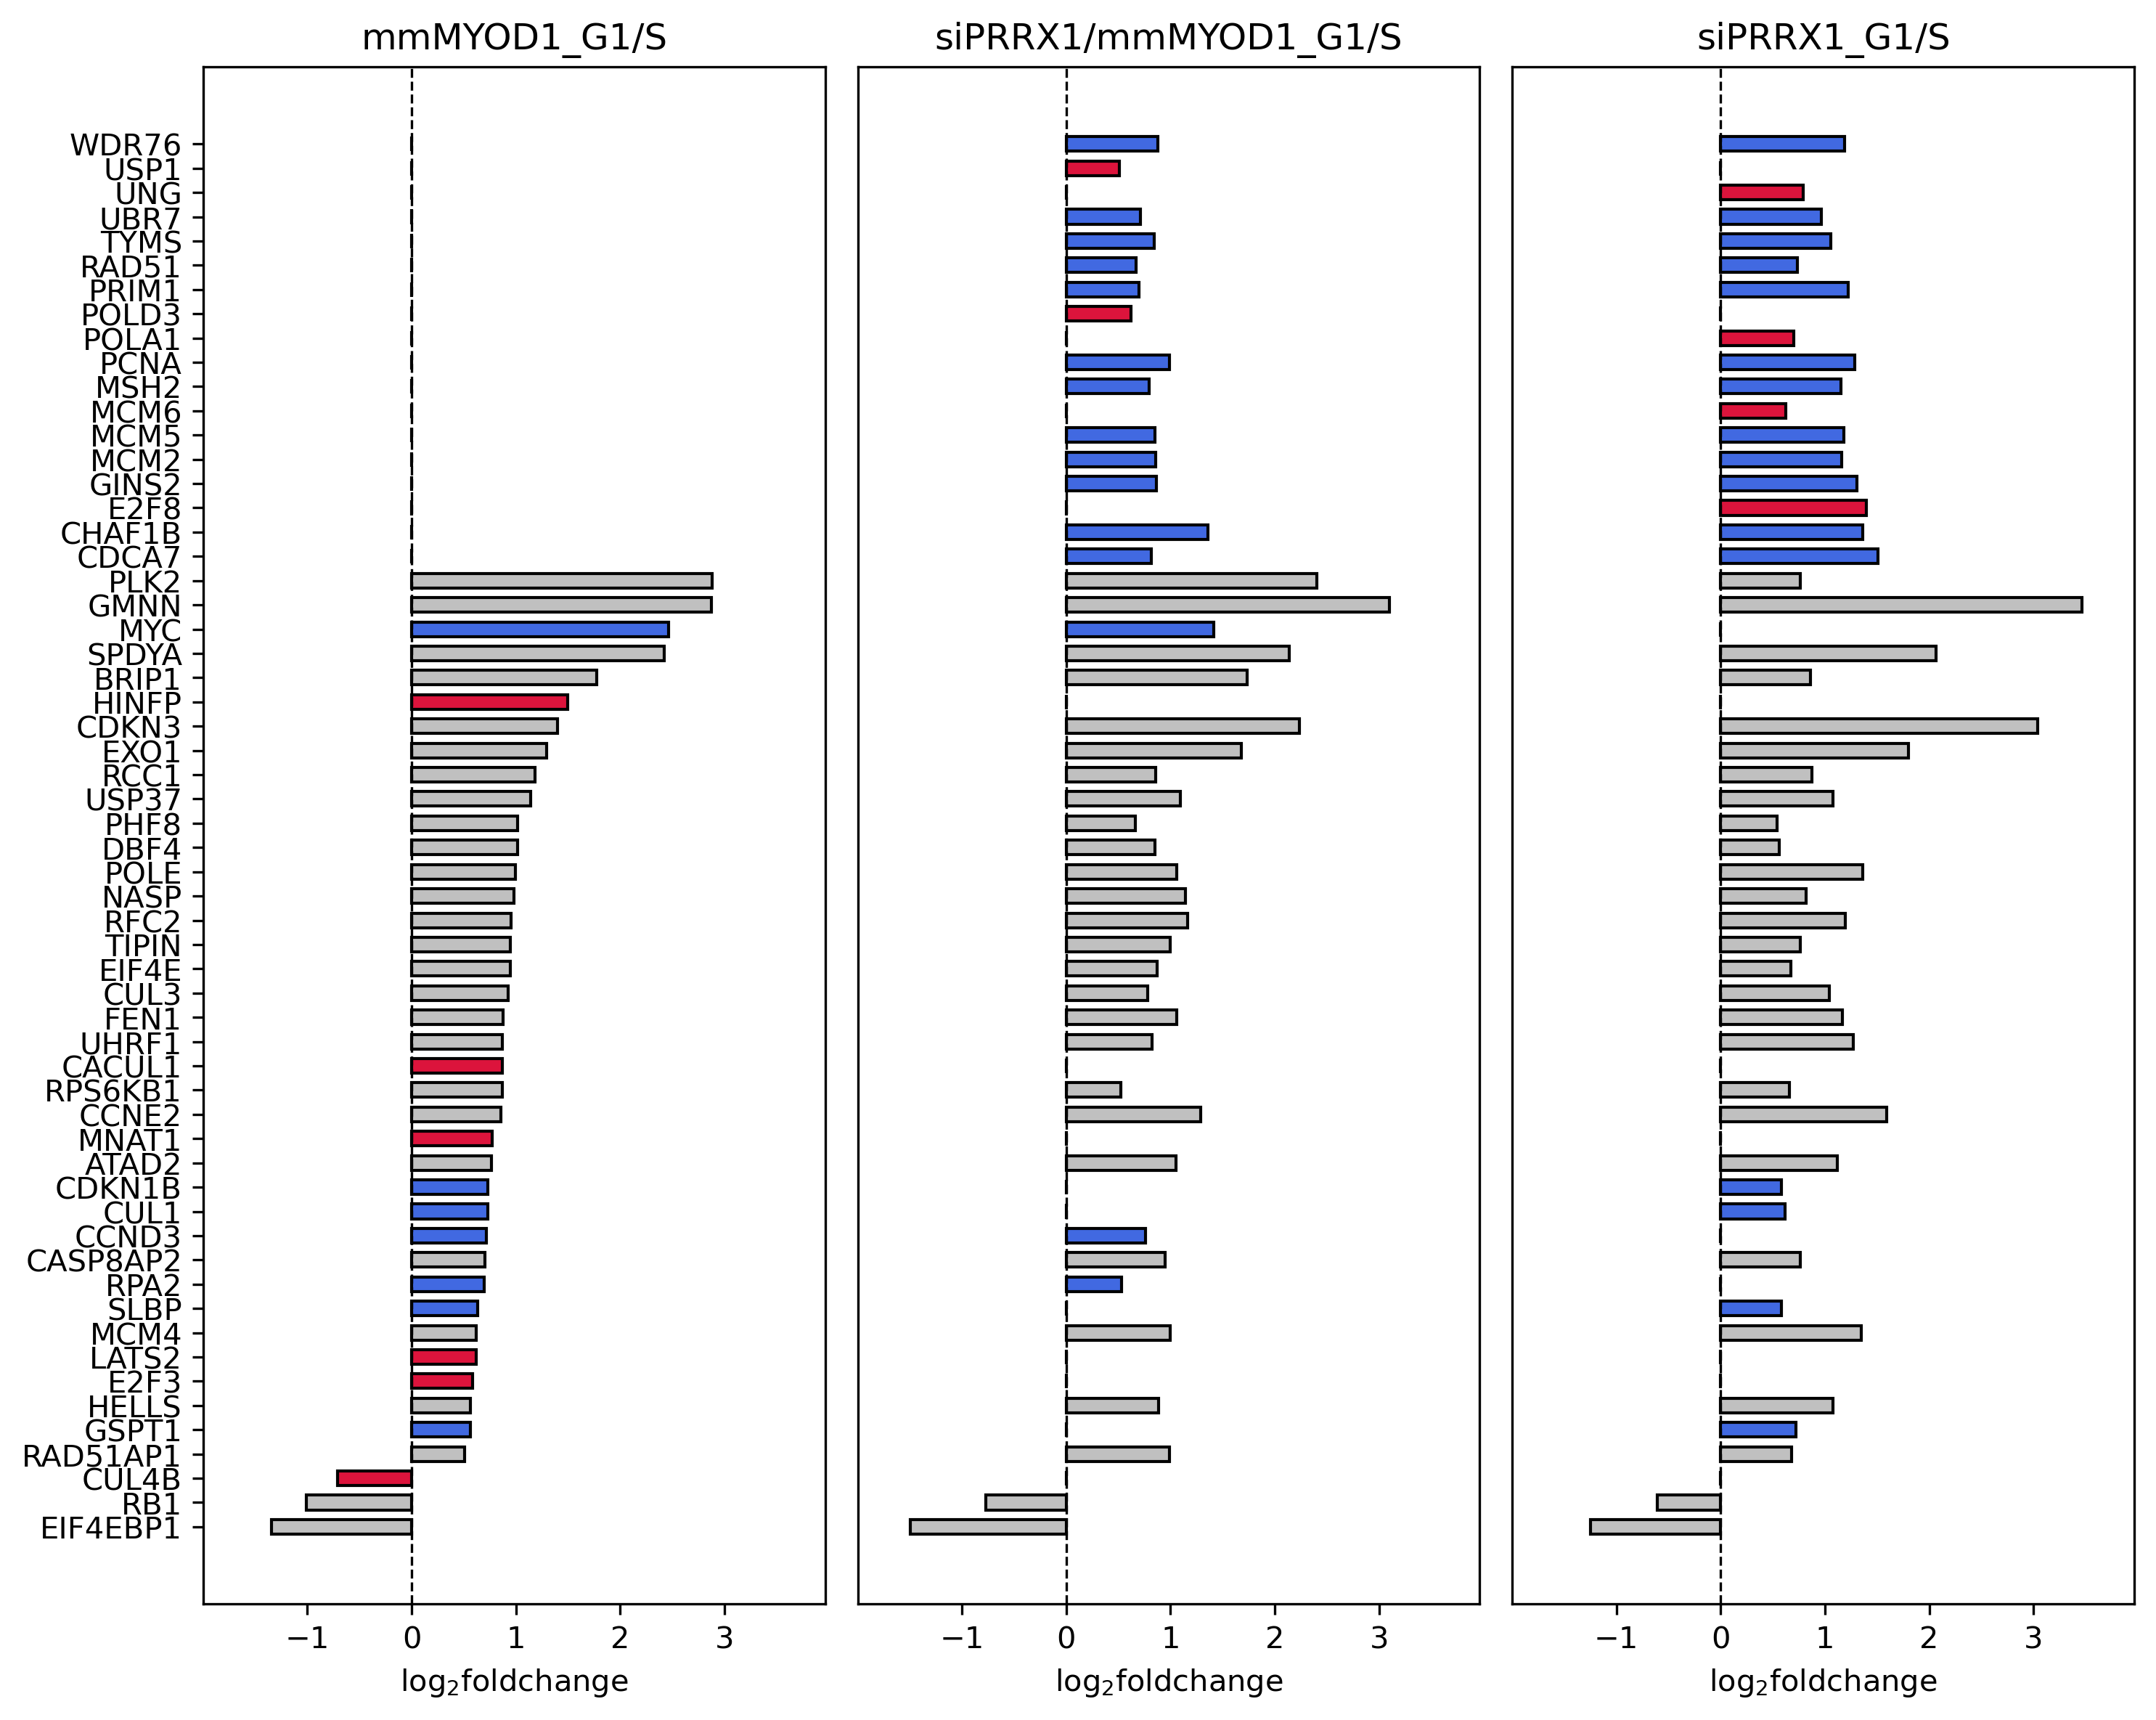

In [107]:
pivot_df = sig.pivot(index="names", columns="group", values="logfoldchanges")

# Pick the first group (by order in sig['group'].unique()) to sort by
first_group = sig["group"].unique()[0]

# Sort by logFC of the first group
pivot_df = pivot_df.sort_values(by=first_group, ascending=True)

min_fc = sig['logfoldchanges'].min()
max_fc = sig['logfoldchanges'].max()


fig, axes = plt.subplots(1, 3, figsize=(10, 8), sharey=True)

for ax, group in zip(axes, pivot_df.columns):
    counts = pivot_df.notna().sum(axis=1)
    values = pivot_df[group]
    colors = []
    for gene, val in values.items():
        if pd.isna(val):
            colors.append("none")  # no bar
        elif counts[gene] == 1:
            colors.append("crimson")
        elif counts[gene] == 2:
            colors.append("royalblue")
        else:
            colors.append("silver")

    ax.barh(pivot_df.index, values.fillna(0), color=colors, edgecolor="black", height=0.6)
    
    ax.set_title(f"{group}")
    ax.set_ylabel("")
    
    if group != pivot_df.columns[0]:
        ax.tick_params(axis="y", which="both", left=False, labelleft=False)
        ax.set_ylabel("")
        
    ax.set_xlabel("log$_2$foldchange")
    ax.axvline(0, color="black", linewidth=0.8, ls='--')
    
    ax.set_xlim([min_fc - 0.5, max_fc + 0.5])

plt.tight_layout()
plt.show()

N unique upregulated genes: 181
N unique downregulated genes: 34



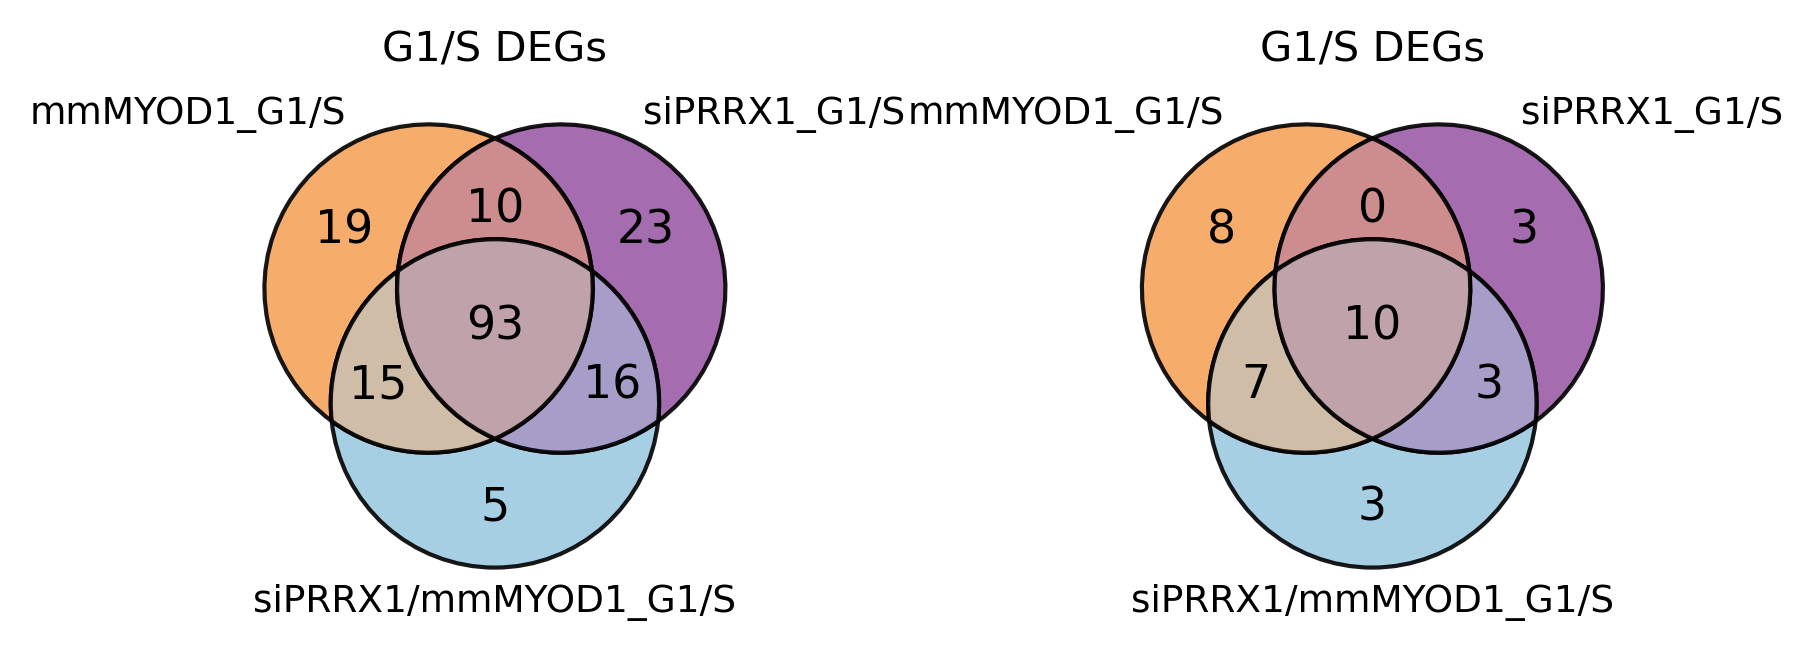

In [111]:
phase = 'G1/S'

up = sig[sig['logfoldchanges'] > 0]
print(f"N unique upregulated genes: {up['names'].nunique()}")

down = sig[sig['logfoldchanges'] < 0]
print(f"N unique downregulated genes: {down['names'].nunique()}\n")


up_sets = up.groupby('group')['names'].apply(set).to_dict()
down_sets = down.groupby('group')['names'].apply(set).to_dict()

# group_names = list(up_sets.keys())  # Assuming same groups in both
# print(group_names)

group_names = [f'mmMYOD1_{phase}', f'siPRRX1_{phase}', f'siPRRX1/mmMYOD1_{phase}']

# Colors
colors_rgb = {
    f'mmMYOD1_{phase}': mcolors.to_rgb('#F5A35B'), # orange
    f'siPRRX1_{phase}': mcolors.to_rgb('#9B5CA6'), # purple
    f'siPRRX1/mmMYOD1_{phase}': mcolors.to_rgb('#9ECAE1') # blue
}

def blend(colors):
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

venn_ids = {
    '100': [f'mmMYOD1_{phase}'],
    '010': [f'siPRRX1_{phase}'],
    '001': [f'siPRRX1/mmMYOD1_{phase}'],
    '110': [f'mmMYOD1_{phase}', f'siPRRX1_{phase}'],
    '101': [f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}'],
    '011': [f'siPRRX1_{phase}', f'siPRRX1/mmMYOD1_{phase}'],
    '111': [f'mmMYOD1_{phase}', f'siPRRX1_{phase}', f'siPRRX1/mmMYOD1_{phase}']
}

# Plotting
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (6, 3)

fig, axs = plt.subplots(1, 2)

for ax, gene_sets, title in zip(axs, [up_sets, down_sets], ['Upregulated', 'Downregulated']):
    plt.sca(ax)  

    venn = venn3_unweighted(
        [gene_sets[group_names[0]], gene_sets[group_names[1]], gene_sets[group_names[2]]],
        set_labels=(group_names[0], group_names[1], group_names[2])
    )

    for label in venn.set_labels:
        if label:
            label.set_fontsize(9)
            
    for subset_id, sets in venn_ids.items():
        patch = venn.get_patch_by_id(subset_id)
        if patch:
            color = blend([colors_rgb[s] for s in sets])
            patch.set_facecolor(color)
            patch.set_edgecolor('k')
            patch.set_linewidth(1)
            patch.set_alpha(0.9)
        label = venn.get_label_by_id(subset_id)
        if label:
            label.set_fontsize(11)
            label.set_horizontalalignment('center')
            label.set_verticalalignment('center')
            x, y = label.get_position()
            offset = 0
            if subset_id == '101':  # nudge left
                offset = -0.04
            elif subset_id == '011': # nudge right
                offset = 0.04
            elif subset_id == '100':
                offset = 0.04
            elif subset_id == '010':
                offset = -0.04
            label.set_position((x + offset, y))
            if subset_id == '001':
                label.set_position((x, y + 0.03))

    ax.set_title(f"{phase} DEGs", fontsize=10)

plt.tight_layout()
plt.show()

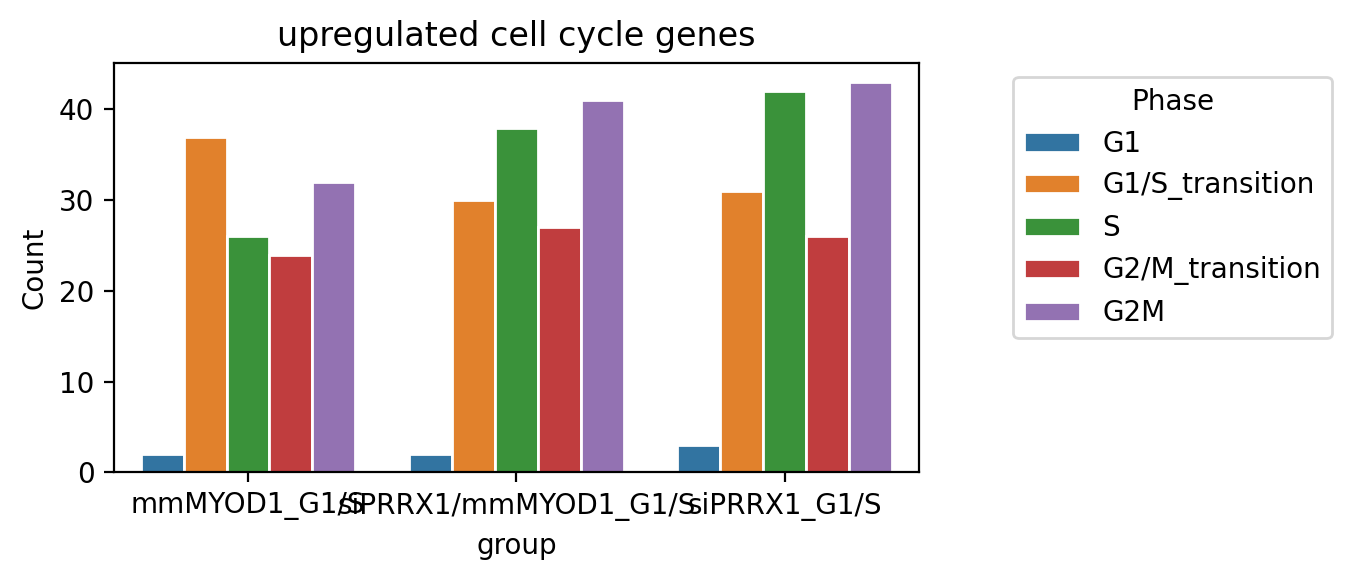

In [16]:
direction = 'upregulated'

if direction == 'upregulated':
    tmp = sig[sig['logfoldchanges'] > 0]
else:
    tmp = sig[sig['logfoldchanges'] < 0]
    
    

counts = tmp.groupby('group')[list(cc_dict.keys())].sum().reset_index()

counts_tidy = counts.melt(id_vars='group', 
                                var_name='Phase', 
                                value_name='Count')


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7, 3

sns.barplot(
    data=counts_tidy,
    x='group',
    y='Count',
    hue='Phase',
    ec='white',
)

sns.move_legend(plt.gca(), loc='upper left', bbox_to_anchor=(1.1, 1))

plt.title(f"{direction} cell cycle genes")

plt.tight_layout()
plt.show()    

In [119]:
sig.sort_values(by='names')['names'].unique()

array(['ACVR1B', 'ANLN', 'ANP32E', 'APP', 'AURKA', 'AURKB', 'BIRC5',
       'BLM', 'BRIP1', 'BRSK1', 'BTN2A2', 'BUB1', 'CACUL1', 'CALM1',
       'CALM2', 'CALM3', 'CASP8AP2', 'CBX5', 'CCDC57', 'CCNA2', 'CCNB1',
       'CCNB2', 'CCND1', 'CCND3', 'CCNE2', 'CCNY', 'CDC20', 'CDC25B',
       'CDC25C', 'CDC6', 'CDC7', 'CDCA2', 'CDCA3', 'CDCA7', 'CDCA8',
       'CDK1', 'CDK6', 'CDKN1A', 'CDKN1B', 'CDKN3', 'CENPA', 'CENPE',
       'CENPF', 'CHAF1B', 'CHEK2', 'CKAP2', 'CKAP2L', 'CKAP5', 'CKS1B',
       'CNOT6', 'CSDE1', 'CUL1', 'CUL3', 'CUL4B', 'DLGAP5', 'DNM2', 'DTL',
       'E2F3', 'E2F8', 'ECT2', 'EIF4E', 'EIF4EBP1', 'ENSA', 'EXO1',
       'FBXL7', 'FOXM1', 'GAS2L3', 'GINS2', 'GMNN', 'GTSE1', 'HBS1L',
       'HINFP', 'HJURP', 'HMGB2', 'HMMR', 'HSPA8', 'ID4', 'IQGAP3',
       'ITGB1', 'KIF11', 'KIF20B', 'KIF23', 'KIF2C', 'LATS1', 'LATS2',
       'LBR', 'LCMT1', 'MASTL', 'MCM2', 'MCM4', 'MCM5', 'MKI67', 'MNAT1',
       'MSH2', 'MYC', 'NASP', 'NCAPD2', 'NDC80', 'NEK2', 'NES', 'NUF2',
       'NU

In [24]:
group = 'siPRRX1'
direction = 'upregulated'

tmp = sig[sig['group'] == group]

if direction == 'upregulated':
    tmp = tmp[tmp['logfoldchanges'] > 0]
else:
    tmp = tmp[tmp['logfoldchanges'] < 0]

print(f"DE {direction} genes for {group} cells: {tmp['names'].nunique()}") 
tmp.sort_values(by='names')['names'].unique()
    
# tmp.head()

DE upregulated genes for siPRRX1 cells: 142


array(['ANLN', 'ANP32E', 'ATAD2', 'AURKA', 'AURKB', 'BIRC5', 'BLM',
       'BRIP1', 'BTN2A2', 'BUB1', 'CASP8AP2', 'CBX5', 'CCDC57', 'CCNA2',
       'CCNB1', 'CCNB2', 'CCND1', 'CCNE2', 'CCNY', 'CDC20', 'CDC25A',
       'CDC25C', 'CDC45', 'CDC6', 'CDC7', 'CDCA2', 'CDCA3', 'CDCA7',
       'CDCA8', 'CDK1', 'CDK14', 'CDK2', 'CDKN1A', 'CDKN1B', 'CDKN3',
       'CENPA', 'CENPE', 'CENPF', 'CHAF1B', 'CHEK1', 'CHEK2', 'CKAP2',
       'CKAP2L', 'CKAP5', 'CKS1B', 'CKS2', 'CLSPN', 'CNOT6', 'CTCF',
       'CUL1', 'CUL3', 'DBF4', 'DLGAP5', 'DNM2', 'DSCC1', 'DTL', 'E2F8',
       'ECT2', 'EIF4E', 'ENSA', 'EXO1', 'EZH2', 'FBXL7', 'FEN1', 'FOXM1',
       'G2E3', 'GAS2L3', 'GINS2', 'GMNN', 'GSPT1', 'GTSE1', 'HBS1L',
       'HELLS', 'HINFP', 'HJURP', 'HMGB2', 'HMMR', 'HSPA8', 'IQGAP3',
       'KHDRBS1', 'KIF11', 'KIF20B', 'KIF23', 'KIF2C', 'LATS1', 'LBR',
       'LCMT1', 'MASTL', 'MCM2', 'MCM4', 'MCM5', 'MCM6', 'MELK', 'MKI67',
       'MSH2', 'NASP', 'NCAPD2', 'NDC80', 'NEK2', 'NES', 'NUF2', 'NUSAP1',
    

In [81]:
cc_cols = list(cc_dict.keys())

tmp = tmp.sort_values(by='names')

for _, row in tmp.iterrows():
    gene = row['names']
    true_phases = [col for col in cc_cols if row[col]]
    print(f"{gene} - {', '.join(true_phases)}")

BRIP1 - S
BTN2A2 - G1/S_transition
CACUL1 - G1/S_transition
CCND3 - G1/S_transition
CCNY - G2/M_transition
CDK6 - G1/S_transition
CHEK2 - G2/M_transition
DNM2 - G2/M_transition
E2F3 - G1/S_transition
FBXL7 - G2/M_transition
GMNN - S
LATS1 - G1/S_transition, G2/M_transition
LATS2 - G1/S_transition
MNAT1 - G1/S_transition
MYC - G1/S_transition
NES - G2/M_transition
PELO - G1, G1/S_transition, S, G2/M_transition, G2M
PHF8 - G1/S_transition
PIAS1 - G1/S_transition
PLK2 - G1/S_transition
PLK3 - G1/S_transition, G2/M_transition
PPM1D - G2/M_transition
SPDYA - G1/S_transition
TERF2 - S
TERF2IP - S


## Overlap by condition

In [122]:
direction = 'Upregulated'

if direction == 'Upregulated':
    tmp = sig[sig['logfoldchanges'] > 0]
else:
    tmp = sig[sig['logfoldchanges'] < 0]

tmp = tmp.sort_values(by=['group', 'names'])

print(f"{direction} cell cycle genes\n")

myod_genes = set(tmp[tmp['group'] == 'mmMYOD1']['names'].unique())
prrx_genes = set(tmp[tmp['group'] == 'siPRRX1']['names'].unique())
hyb_genes = set(tmp[tmp['group'] == 'siPRRX1/mmMYOD1']['names'].unique())

print(f"Unique to mmMYOD1: {sorted(myod_genes - prrx_genes - hyb_genes)}\n")
print(f"Unique to siPRRX1: {sorted(prrx_genes - myod_genes - hyb_genes)}\n")
print(f"Unique to siPRRX1/mmMYOD1: {sorted(hyb_genes - myod_genes - prrx_genes)}\n")

print(f"Shared between mmMYOD1 + siPRRX1: {sorted((prrx_genes.intersection(myod_genes)) - hyb_genes)}\n")
print(f"Shared between mmMYOD1 + siPRRX1/mmMYOD1: {sorted((hyb_genes.intersection(myod_genes)) - prrx_genes)}\n")
print(f"Shared between siPRRX1 + siPRRX1/mmMYOD1: {sorted((hyb_genes.intersection(prrx_genes)) - myod_genes)}\n")
print(f"Shared by all: {sorted(hyb_genes.intersection(prrx_genes).intersection(myod_genes))}\n")

Upregulated cell cycle genes

Unique to mmMYOD1: ['ACVR1B', 'CACUL1', 'CDK6', 'E2F3', 'LATS2', 'LCMT1', 'MNAT1', 'TAF2', 'TERF2IP']

Unique to siPRRX1: ['AURKA', 'BIRC5', 'BUB1', 'CCNB1', 'CDC20', 'CDC7', 'CDKN1B', 'CDKN3', 'CENPF', 'CKAP5', 'CNOT6', 'DLGAP5', 'GINS2', 'HBS1L', 'HSPA8', 'LBR', 'MCM2', 'MCM4', 'MCM5', 'MKI67', 'MSH2', 'NCAPD2', 'PCNA', 'PLK1', 'POLE', 'RRM2', 'SMC4', 'TPX2', 'UBR7', 'UHRF1', 'WDR76']

Unique to siPRRX1/mmMYOD1: ['RANGAP1']

Shared between mmMYOD1 + siPRRX1: ['BRSK1', 'CCDC57', 'CUL1', 'GAS2L3', 'HINFP', 'RCC1', 'RPS6KB1']

Shared between mmMYOD1 + siPRRX1/mmMYOD1: ['CCND3', 'EIF4E', 'MASTL', 'MYC', 'PLK3', 'TIPIN']

Shared between siPRRX1 + siPRRX1/mmMYOD1: ['BLM', 'CDCA7', 'CHAF1B', 'DTL', 'EXO1']

Shared by all: ['BRIP1', 'BTN2A2', 'CASP8AP2', 'CCND1', 'CCNE2', 'CCNY', 'CDC6', 'CDKN1A', 'CHEK2', 'CUL3', 'DNM2', 'ENSA', 'FBXL7', 'GMNN', 'LATS1', 'NASP', 'NES', 'PELO', 'PHF8', 'PIAS1', 'PLCB1', 'PLK2', 'PPM1D', 'RFC2', 'RTEL1', 'SKP2', 'SPDYA', 'TERF2',